# MCDI504 Machine Learning I: Informe Final de Proyecto - Fases 2 y 3

**Caso de aplicación:** CuídateDeLaDiabete - Diabetes Prediction in India Dataset (Kaggle). 
**Integrantes:** Cristian Pastén, Enso Guidotti, Daniel Hormazábal. 
**Grupo:** 02. 

Este notebook implementa y evalúa, sobre el mismo dataset e hitos de preparación definidos en la Fase 1 del proyecto (F1_Definicion.ipynb):

- **Regresión supervisada** (Fase 2): un perceptrón multicapa (MLPRegressor) con ajuste de hiperparámetros, comparado contra una regresión lineal como modelo base, para predecir una variable clínica continua.
- **Clasificación supervisada** (Fase 3): modelos tradicionales (KNN, árbol de decisión, SVM, Naive Bayes) como referencia comparativa, y tres arquitecturas de red neuronal (perceptrón multicapa con una, dos y tres capas ocultas).

## 1. Carga de librerías

In [1]:
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.exceptions import ConvergenceWarning
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.metrics import roc_auc_score
from scipy.stats import binomtest

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

# ---------------------------------------------------------------------------
# Paleta grafica unificada del informe.
# Criterio: escala de grises para los datos y un unico color de acento
# reservado para las lineas de referencia (azar, linea base, prediccion
# perfecta). Garantiza coherencia visual entre todas las figuras y
# legibilidad en impresion monocroma.
# ---------------------------------------------------------------------------
GRIS_CLARO   = '#D4D4D4'
GRIS_MEDIO   = '#9A9A9A'
GRIS_OSCURO  = '#4A4A4A'
ACENTO       = '#B3452F'          # solo para lineas de referencia
PALETA_2     = [GRIS_MEDIO, GRIS_OSCURO]
PALETA_3     = [GRIS_CLARO, GRIS_MEDIO, GRIS_OSCURO]
PALETA_4     = ['#DCDCDC', '#A8A8A8', '#6E6E6E', '#3A3A3A']
CMAP_SEC     = 'Greys'            # mapas secuenciales (matrices de confusion)
CMAP_DIV     = 'RdGy_r'           # mapas divergentes (correlaciones)

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.titlesize': 11,
    'axes.labelsize': 9,
    'font.size': 9,
})

## 2. Carga de datos

Se reutiliza el dataset `diabetes_prediction_india.csv` definido y caracterizado en la Fase 1 del proyecto (5.292 fichas de pacientes, 27 variables clínicas, antropométricas y de estilo de vida).

In [2]:
df = pd.read_csv('../data/diabetes_prediction_india.csv')
print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head()

Dimensiones del dataset: 5292 filas x 27 columnas


,Age,Gender,BMI,Family_History,Physical_Activity,Diet_Type,Smoking_Status,Alcohol_Intake,Stress_Level,Hypertension,Cholesterol_Level,Fasting_Blood_Sugar,Postprandial_Blood_Sugar,HBA1C,Heart_Rate,Waist_Hip_Ratio,Urban_Rural,Health_Insurance,Regular_Checkups,Medication_For_Chronic_Conditions,Pregnancies,Polycystic_Ovary_Syndrome,Glucose_Tolerance_Test_Result,Vitamin_D_Level,C_Protein_Level,Thyroid_Condition,Diabetes_Status
0,48,Male,35.5,No,High,Non-Vegetarian,Never,NaN,Medium,Yes,111.7,141.0,165.6,8.9,94,0.91,Urban,No,No,No,0,0,124.3,31.5,7.46,Yes,Yes
1,18,Other,28.7,Yes,Medium,Non-Vegetarian,Current,Moderate,High,No,130.6,83.1,142.6,5.9,68,0.96,Rural,Yes,Yes,No,0,0,151.4,12.5,5.64,Yes,No
2,21,Other,30.0,Yes,High,Non-Vegetarian,Current,Moderate,High,Yes,294.8,159.9,212.4,4.8,70,0.88,Rural,No,No,Yes,0,0,106.1,35.8,7.20,No,Yes
3,25,Female,25.6,No,Medium,Vegetarian,Former,Moderate,High,Yes,159.1,133.3,225.4,11.9,78,0.98,Rural,No,No,Yes,1,No,85.6,15.4,6.53,Yes,No
4,78,Male,38.8,No,High,Non-Vegetarian,Current,High,High,No,215.0,164.9,218.1,11.6,65,0.85,Urban,No,No,Yes,0,0,77.0,28.6,0.58,No,Yes


## 3. Descripción del conjunto de datos y preparación analítica para regresión supervisada

**Variable objetivo-continua:** `HBA1C` (hemoglobina glicosilada, expresada en %). Se selecciona esta variable, entre las candidatas continuas del dataset (`HBA1C`, `Fasting_Blood_Sugar`, `Postprandial_Blood_Sugar`, `BMI`, `Cholesterol_Level`), porque constituye el marcador clínico estándar de control glucémico a mediano plazo (promedio de 2 a 3 meses) y es la variable con mayor relevancia diagnóstica directa para el caso CuídateDeLaDiabete, al ser uno de los criterios de laboratorio utilizados en la práctica clínica para el diagnóstico y seguimiento de la diabetes.

**Variables predictoras:** el resto de las variables clínicas, antropométricas y de estilo de vida disponibles (11 numéricas y 14 categóricas), excluyendo explícitamente:
- `HBA1C`, por ser la variable objetivo.
- `Diabetes_Status`, para evitar mezclar el problema de regresión con el problema de clasificación abordado en la sección 8 y siguientes, y para evaluar la capacidad predictiva de las variables clínicas independientes sobre `HBA1C`.

**Tratamiento de datos faltantes:** se hereda el mismo tratamiento documentado en la Fase 1 y aplicado en la sección de clasificación: `Alcohol_Intake` (33,6% de valores faltantes) se recodifica con la categoría explícita `'No_Registrado'`, y `Polycystic_Ovary_Syndrome` recodifica `'0'` (no aplica biológicamente) como `'No_Aplica'`. La variable objetivo `HBA1C` no presenta valores faltantes (0 de 5.292 registros).

In [3]:
df_reg = df.copy()

# Mismo tratamiento de valores faltantes documentado en la Fase 1
df_reg['Alcohol_Intake'] = df_reg['Alcohol_Intake'].fillna('No_Registrado')
df_reg['Polycystic_Ovary_Syndrome'] = df_reg['Polycystic_Ovary_Syndrome'].replace('0', 'No_Aplica')

print(f"Valores faltantes en HBA1C (variable objetivo): {df_reg['HBA1C'].isnull().sum()}")
print(f"Valores nulos restantes en el dataset: {df_reg.isnull().sum().sum()}")
df_reg['HBA1C'].describe().round(2)

Valores faltantes en HBA1C (variable objetivo): 0
Valores nulos restantes en el dataset: 0


count    5292.00
mean        8.23
std         2.18
min         4.50
25%         6.30
50%         8.20
75%        10.10
max        12.00
Name: HBA1C, dtype: float64

**Transformación de variables:** las variables categóricas se codifican mediante One-Hot Encoding (`drop_first=True`, evitando multicolinealidad), replicando el criterio usado en la preparación para redes neuronales de clasificación. Las variables numéricas se estandarizan con `StandardScaler`, ajustado únicamente sobre el conjunto de entrenamiento, dado que el algoritmo de referencia (MLPRegressor) es igualmente sensible a la escala de las variables de entrada que su contraparte de clasificación.

**Selección de variables:** se conservan todas las variables predictoras disponibles tras la codificación, sin descartes adicionales, dado que la Fase 1 no identificó redundancias críticas más allá de las ya tratadas.

In [4]:
cat_cols_reg = [c for c in df_reg.select_dtypes(include=['object', 'string']).columns if c not in ['Diabetes_Status']]
num_cols_reg = [c for c in df_reg.select_dtypes(include='number').columns if c not in ['HBA1C']]

df_reg_encoded = pd.get_dummies(df_reg.drop(columns=['Diabetes_Status']), columns=cat_cols_reg, drop_first=True)

X_reg = df_reg_encoded.drop(columns=['HBA1C'])
y_reg = df_reg_encoded['HBA1C']

print(f"X_reg: {X_reg.shape}  y_reg: {y_reg.shape}")
print(f"Media de HBA1C: {y_reg.mean():.3f}  Desviación estándar: {y_reg.std():.3f}")

X_reg: (5292, 32)  y_reg: (5292,)
Media de HBA1C: 8.227  Desviación estándar: 2.180


**Partición entrenamiento/prueba:** se utiliza una partición 80/20 con semilla fija (`random_state=42`) para reproducibilidad. A diferencia de la partición usada para clasificación, aquí **no se aplica estratificación** (`stratify=None`), dado que la estratificación es una técnica propia de variables objetivo categóricas orientada a preservar el balance de clases; `HBA1C` es una variable continua y no admite ese criterio de partición.

In [5]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.20, random_state=RANDOM_STATE
)

print("X_train_reg:", X_train_reg.shape, " X_test_reg:", X_test_reg.shape)
print(f"Media HBA1C train: {y_train_reg.mean():.3f}  Media HBA1C test: {y_test_reg.mean():.3f}")

X_train_reg: (4233, 32)  X_test_reg: (1059, 32)
Media HBA1C train: 8.244  Media HBA1C test: 8.157


In [6]:
scaler_reg = StandardScaler()
X_train_reg_scaled = X_train_reg.copy()
X_test_reg_scaled = X_test_reg.copy()
X_train_reg_scaled[num_cols_reg] = scaler_reg.fit_transform(X_train_reg[num_cols_reg])
X_test_reg_scaled[num_cols_reg] = scaler_reg.transform(X_test_reg[num_cols_reg])

X_train_reg_scaled[num_cols_reg].describe().round(2).T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
Age,-0.0,1.0,-1.68,1.69
BMI,-0.0,1.0,-1.74,1.75
Cholesterol_Level,0.0,1.0,-1.75,1.75
Fasting_Blood_Sugar,-0.0,1.0,-1.71,1.71
Postprandial_Blood_Sugar,-0.0,1.0,-1.72,1.74
Heart_Rate,-0.0,1.0,-1.74,1.68
Waist_Hip_Ratio,-0.0,1.0,-1.72,1.74
Pregnancies,-0.0,1.0,-0.56,2.80
Glucose_Tolerance_Test_Result,0.0,1.0,-1.73,1.73
Vitamin_D_Level,-0.0,1.0,-1.72,1.74


**Justificación técnica de la preparación realizada:** el pipeline de preparación para regresión replica, de manera consistente, las decisiones técnicas ya justificadas y aplicadas en la Fase 1 y en la preparación para redes neuronales de clasificación (tratamiento de valores faltantes, codificación One-Hot, estandarización ajustada solo en entrenamiento), con dos ajustes propios del problema de regresión: la exclusión de `Diabetes_Status` del conjunto de predictores y la ausencia de estratificación en la partición entrenamiento/prueba. Esta coherencia metodológica permite comparar los resultados de ambos problemas (regresión y clasificación) bajo el mismo estándar de preparación de datos.

## 4. Implementación del modelo de regresión supervisada

**Algoritmo implementado:** perceptrón multicapa para regresión (`MLPRegressor`).

**Justificación técnica de elección:** se selecciona un MLP como modelo principal de regresión por continuidad metodológica con el enfoque de redes neuronales adoptado en el resto del proyecto, y porque, al no asumir una forma funcional lineal entre predictores y variable objetivo, permite evaluar si existe una relación no lineal aprovechable con `HBA1C` que un modelo lineal simple no podría capturar. Esto es especialmente relevante dado que la Fase 1 no encontró correlaciones lineales significativas entre las variables numéricas y la variable objetivo de clasificación (`Diabetes_Status`), por lo que resulta pertinente descartar también relaciones no lineales sobre esta variable continua.

**Configuración inicial:** arquitectura intermedia de dos capas ocultas (100 y 50 neuronas), activación ReLU, optimizador Adam, máximo 500 iteraciones y semilla fija, análoga a la arquitectura de dos capas evaluada en la sección de clasificación.

In [7]:
mlp_reg_inicial = MLPRegressor(hidden_layer_sizes=(100, 50), activation='relu', solver='adam',
                                max_iter=500, random_state=RANDOM_STATE)

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always', ConvergenceWarning)
    mlp_reg_inicial.fit(X_train_reg_scaled, y_train_reg)
    convergio_reg_inicial = not any(issubclass(x.category, ConvergenceWarning) for x in w)

y_pred_reg_inicial = mlp_reg_inicial.predict(X_test_reg_scaled)
mse_inicial = mean_squared_error(y_test_reg, y_pred_reg_inicial)
r2_inicial = r2_score(y_test_reg, y_pred_reg_inicial)

print(f"Iteraciones utilizadas: {mlp_reg_inicial.n_iter_} / max_iter={mlp_reg_inicial.max_iter} | Convergencia: {'Si' if convergio_reg_inicial else 'No (alcanzo max_iter)'}")
print(f"MSE inicial: {mse_inicial:.4f}  RMSE inicial: {np.sqrt(mse_inicial):.4f}  R2 inicial: {r2_inicial:.4f}")

Iteraciones utilizadas: 493 / max_iter=500 | Convergencia: Si
MSE inicial: 11.6541  RMSE inicial: 3.4138  R2 inicial: -1.4886


**Resultados iniciales:** la configuración inicial obtiene un R² de -1,49 y un RMSE de 3,41, notoriamente peor que la desviación estándar de `HBA1C` en el conjunto de prueba (2,17). Un R² negativo indica que el modelo generaliza peor que la alternativa trivial de predecir el promedio de `HBA1C` para todos los pacientes: la arquitectura de dos capas ocultas, al tener mayor capacidad, ajusta ruido específico del conjunto de entrenamiento (sobreajuste) en ausencia de una señal real que aprovechar. Este resultado inicial se profundiza y se somete a ajuste de hiperparámetros en la sección siguiente.

## 5. Ajuste de hiperparámetros del modelo de regresión

Se documentan tres configuraciones evaluadas, variando dos hiperparámetros relevantes para un MLP: la arquitectura de capas ocultas (`hidden_layer_sizes`) y el parámetro de regularización L2 (`alpha`).

- **Configuración A:** una capa oculta de 50 neuronas, `alpha=0.0001` (valor por defecto). Arquitectura más simple, para evaluar si una red menos compleja generaliza mejor.
- **Configuración B:** dos capas ocultas (100, 50), `alpha=0.0001`. Corresponde a la configuración inicial de la sección 4, usada como referencia.
- **Configuración C:** dos capas ocultas (100, 50), `alpha=0.01`. Misma arquitectura que B, con mayor regularización L2 para evaluar si penalizar la magnitud de los pesos mejora la generalización.

In [8]:
configuraciones_reg = {
    'A: (50,) alpha=0.0001': MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, activation='relu',
                                           solver='adam', max_iter=500, random_state=RANDOM_STATE),
    'B: (100,50) alpha=0.0001': MLPRegressor(hidden_layer_sizes=(100, 50), alpha=0.0001, activation='relu',
                                              solver='adam', max_iter=500, random_state=RANDOM_STATE),
    'C: (100,50) alpha=0.01': MLPRegressor(hidden_layer_sizes=(100, 50), alpha=0.01, activation='relu',
                                            solver='adam', max_iter=500, random_state=RANDOM_STATE),
}

resultados_ajuste = []
for nombre_cfg, modelo_cfg in configuraciones_reg.items():
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter('always', ConvergenceWarning)
        modelo_cfg.fit(X_train_reg_scaled, y_train_reg)
        convergio_cfg = not any(issubclass(x.category, ConvergenceWarning) for x in w)
    y_pred_cfg = modelo_cfg.predict(X_test_reg_scaled)
    mse_cfg = mean_squared_error(y_test_reg, y_pred_cfg)
    resultados_ajuste.append({
        'Configuración': nombre_cfg,
        'MSE': mse_cfg,
        'RMSE': np.sqrt(mse_cfg),
        'R2': r2_score(y_test_reg, y_pred_cfg),
        'Iteraciones': modelo_cfg.n_iter_,
        'Convergencia': 'Si' if convergio_cfg else 'No'
    })

df_ajuste_reg = pd.DataFrame(resultados_ajuste)
df_ajuste_reg.round(4)

,Configuración,MSE,RMSE,R2,Iteraciones,Convergencia
0,"A: (50,) alpha=0.0001",6.1547,2.4809,-0.3143,500,No
1,"B: (100,50) alpha=0.0001",11.6541,3.4138,-1.4886,493,Si
2,"C: (100,50) alpha=0.01",11.0777,3.3283,-1.3656,438,Si


**Comparación de resultados entre configuraciones y justificación técnica:** las tres configuraciones obtienen R² negativo, pero con diferencias relevantes entre ellas. La configuración A (una sola capa oculta de 50 neuronas) obtiene el R² menos desfavorable (-0,31) y el menor RMSE (2,48) de las tres, mientras que las configuraciones B y C, con mayor capacidad (dos capas ocultas), obtienen resultados sustancialmente peores (R² de -1,49 y -1,37 respectivamente). Aumentar la regularización L2 sobre la arquitectura de dos capas (configuración C) atenúa levemente el sobreajuste observado en B, pero no logra igualar a la arquitectura más simple. Se selecciona la **configuración A (una capa oculta de 50 neuronas, alpha=0,0001)** como configuración final, dado que es la que mejor generaliza sobre el conjunto de prueba: en un problema sin señal explotable, reducir la capacidad del modelo limita su capacidad de ajustar ruido del conjunto de entrenamiento.

In [9]:
mlp_reg_final = configuraciones_reg['A: (50,) alpha=0.0001']
y_pred_reg_final = mlp_reg_final.predict(X_test_reg_scaled)

### 5.1 Verificación de convergencia de la configuración seleccionada

La configuración A alcanza el máximo de iteraciones (`max_iter=500`) sin emitir señal de convergencia, mientras que B y C sí convergen. Para descartar que su mejor desempeño relativo sea un artefacto de entrenamiento incompleto (una red sub-entrenada ajusta menos ruido y puede parecer que generaliza mejor), se reentrena la misma arquitectura con un presupuesto mayor de iteraciones y se compara contra el resultado de referencia.

In [10]:
# Verificacion: misma arquitectura de la configuracion A, con mayor presupuesto de iteraciones
mlp_reg_A_conv = MLPRegressor(hidden_layer_sizes=(50,), alpha=0.0001, activation='relu',
                              solver='adam', max_iter=2000, random_state=RANDOM_STATE)

with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter('always', ConvergenceWarning)
    mlp_reg_A_conv.fit(X_train_reg_scaled, y_train_reg)
    convergio_A = not any(issubclass(x.category, ConvergenceWarning) for x in w)

y_pred_A_conv = mlp_reg_A_conv.predict(X_test_reg_scaled)
mse_A_conv = mean_squared_error(y_test_reg, y_pred_A_conv)

# Referencia: configuracion A tal como se selecciono en la seccion 5 (max_iter=500)
mse_A_ref = mean_squared_error(y_test_reg, y_pred_reg_final)
r2_A_ref = r2_score(y_test_reg, y_pred_reg_final)

df_convergencia = pd.DataFrame([
    {'Configuracion A': 'max_iter=500 (seleccionada)',
     'Iteraciones': mlp_reg_final.n_iter_,
     'MSE': mse_A_ref, 'RMSE': np.sqrt(mse_A_ref), 'R2': r2_A_ref},
    {'Configuracion A': 'max_iter=2000 (verificacion)',
     'Iteraciones': mlp_reg_A_conv.n_iter_,
     'MSE': mse_A_conv, 'RMSE': np.sqrt(mse_A_conv),
     'R2': r2_score(y_test_reg, y_pred_A_conv)},
])

print(f"Convergencia con max_iter=2000: {'Si' if convergio_A else 'No (alcanzo max_iter)'}\n")
print("El modelo final reportado en las secciones 6 y 7 sigue siendo la configuracion A")
print("con max_iter=500; esta celda documenta unicamente la verificacion de convergencia.\n")
df_convergencia.round(4)

Convergencia con max_iter=2000: Si

El modelo final reportado en las secciones 6 y 7 sigue siendo la configuracion A
con max_iter=500; esta celda documenta unicamente la verificacion de convergencia.



,Configuracion A,Iteraciones,MSE,RMSE,R2
0,max_iter=500 (seleccionada),500,6.1547,2.4809,-0.3143
1,max_iter=2000 (verificacion),744,6.5111,2.5517,-0.3904


## 6. Evaluación de desempeño mediante métricas de regresión

Se calculan las métricas estándar de evaluación de modelos de regresión (MSE, RMSE y R²) sobre el conjunto de prueba, para el modelo final seleccionado en la sección anterior.

In [11]:
mse_final = mean_squared_error(y_test_reg, y_pred_reg_final)
rmse_final = np.sqrt(mse_final)
r2_final = r2_score(y_test_reg, y_pred_reg_final)

df_metricas_reg = pd.DataFrame([{
    'Modelo': 'MLPRegressor (50,)',
    'MSE': mse_final,
    'RMSE': rmse_final,
    'R2': r2_final
}])
df_metricas_reg.round(4)

,Modelo,MSE,RMSE,R2
0,"MLPRegressor (50,)",6.1547,2.4809,-0.3143


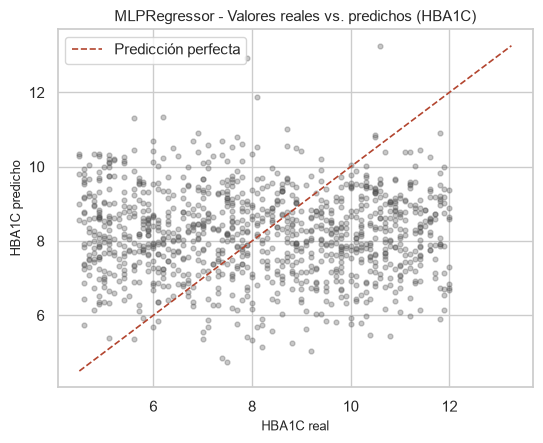

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.scatter(y_test_reg, y_pred_reg_final, alpha=0.3, s=12, color=GRIS_OSCURO)
lims = [min(y_test_reg.min(), y_pred_reg_final.min()), max(y_test_reg.max(), y_pred_reg_final.max())]
ax.plot(lims, lims, color=ACENTO, linestyle='--', linewidth=1.2, label='Predicción perfecta')
ax.set_xlabel('HBA1C real')
ax.set_ylabel('HBA1C predicho')
ax.set_title('MLPRegressor - Valores reales vs. predichos (HBA1C)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/f3_fig_reg_dispersion.png', dpi=150)
plt.show()

**Interpretación técnica de las métricas obtenidas:** el modelo final (configuración A) obtiene un RMSE de 2,48 puntos porcentuales de HBA1C, superior a la desviación estándar de la variable objetivo en el conjunto de prueba (2,17), y un R² de -0,31. Un R² negativo indica que, incluso en su configuración más simple, el MLPRegressor generaliza peor sobre datos no vistos que la alternativa trivial de predecir el promedio de `HBA1C` para todos los pacientes. Esto confirma que las variables clínicas, antropométricas y de estilo de vida disponibles no contienen una señal aprovechable para predecir `HBA1C`, y que la flexibilidad adicional de una red neuronal, lejos de ayudar, favorece el sobreajuste cuando esa señal no existe. El gráfico de dispersión entre valores reales y predichos muestra una nube de puntos sin relación aparente con la diagonal de predicción perfecta, consistente con la ausencia de señal explotable ya documentada en la Fase 1 para la variable de clasificación.

## 7. Comparación técnica entre modelos de regresión

Se compara el modelo MLPRegressor final contra un modelo de regresión lineal simple (`LinearRegression`) como línea base, para evaluar si la capacidad no lineal del perceptrón multicapa aporta una ventaja de desempeño frente al modelo lineal más simple posible.

In [13]:
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_reg_scaled, y_train_reg)
y_pred_lineal = modelo_lineal.predict(X_test_reg_scaled)

mse_lineal = mean_squared_error(y_test_reg, y_pred_lineal)
r2_lineal = r2_score(y_test_reg, y_pred_lineal)

# Linea base trivial: predecir siempre la media de HBA1C del conjunto de entrenamiento.
# Define el piso de referencia contra el que se interpreta cualquier R2.
dummy_reg = DummyRegressor(strategy='mean')
dummy_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_dummy = dummy_reg.predict(X_test_reg_scaled)
mse_dummy = mean_squared_error(y_test_reg, y_pred_dummy)
r2_dummy = r2_score(y_test_reg, y_pred_dummy)

df_comparacion_reg = pd.DataFrame([
    {'Modelo': 'Linea base (media)', 'MSE': mse_dummy, 'RMSE': np.sqrt(mse_dummy), 'R2': r2_dummy},
    {'Modelo': 'Regresion Lineal', 'MSE': mse_lineal, 'RMSE': np.sqrt(mse_lineal), 'R2': r2_lineal},
    {'Modelo': 'MLPRegressor (50,)', 'MSE': mse_final, 'RMSE': rmse_final, 'R2': r2_final},
])
df_comparacion_reg.round(4)

,Modelo,MSE,RMSE,R2
0,Linea base (media),4.6905,2.1658,-0.0016
1,Regresion Lineal,4.7161,2.1717,-0.0071
2,"MLPRegressor (50,)",6.1547,2.4809,-0.3143


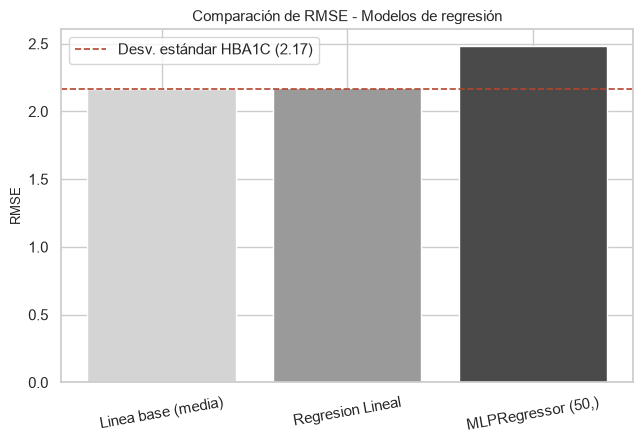

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.bar(df_comparacion_reg['Modelo'], df_comparacion_reg['RMSE'], color=PALETA_3)
ax.axhline(y_test_reg.std(), color=ACENTO, linestyle='--', linewidth=1.2, label=f'Desv. estándar HBA1C ({y_test_reg.std():.2f})')
ax.set_ylabel('RMSE')
ax.set_title('Comparación de RMSE - Modelos de regresión')
ax.legend()
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('../figures/f3_fig_reg_comparacion.png', dpi=150)
plt.show()

**Fortalezas observadas:** la regresión lineal obtiene el mejor resultado de las dos alternativas comparadas (R² de -0,01, prácticamente equivalente a predecir el promedio de `HBA1C`), además de ser un modelo más simple e interpretable (permite examinar directamente los coeficientes asociados a cada predictor) y de menor costo computacional. El MLPRegressor, incluso en su configuración más simple (una capa oculta), obtiene un R² más negativo (-0,31), es decir, generaliza peor que el modelo lineal.

**Limitaciones observadas:** ninguno de los dos modelos logra un poder predictivo relevante sobre `HBA1C`; la diferencia entre ambos no refleja que el MLP haya encontrado una relación no lineal útil, sino que su mayor flexibilidad, en ausencia de una señal real, le permite ajustar ruido específico del conjunto de entrenamiento (sobreajuste), lo que perjudica su desempeño de generalización frente al modelo lineal, más restringido.

**Justificación técnica de la selección final:** se selecciona la **regresión lineal** como modelo recomendado entre los dos comparados, dado que obtiene el desempeño de generalización menos desfavorable y no presenta el sobreajuste observado en el MLPRegressor. Esta conclusión no invalida el enfoque de redes neuronales adoptado en el resto del informe, sino que ilustra un principio metodológico relevante: cuando no existe una relación explotable entre los predictores y la variable objetivo, la mayor capacidad de un modelo no lineal puede ser contraproducente, y un modelo lineal simple constituye una línea base más robusta. Esta conclusión es coherente con el hallazgo de la Fase 1 sobre la posible naturaleza sintética del dataset: si las variables clínicas no guardan relación real con los indicadores de diabetes, ningún algoritmo de regresión, lineal o no lineal, puede superar sistemáticamente ese límite.

## 8. Descripción del conjunto de datos y preparación para redes neuronales

**Variable objetivo:** `Diabetes_Status` (Yes/No), recodificada a 1/0 para el modelamiento.<br>
**Variables predictoras:** 12 numéricas (Age, BMI, Cholesterol_Level, Fasting_Blood_Sugar, Postprandial_Blood_Sugar, HBA1C, Heart_Rate, Waist_Hip_Ratio, Pregnancies, Glucose_Tolerance_Test_Result, Vitamin_D_Level, C_Protein_Level) y 14 categóricas.

De la Fase 1 se heredan dos hallazgos de calidad de datos que deben tratarse antes del modelamiento:
- `Alcohol_Intake` presenta 33,6% de valores faltantes (1.780 de 5.292 registros).
- `Polycystic_Ovary_Syndrome` presenta una codificación mixta: `'0'` para registros donde la variable no aplica biológicamente (Male/Other) y `'Yes'`/`'No'` para el diagnóstico real en pacientes Female.

In [15]:
df_proc = df.copy()

# Tratamiento de valores faltantes en Alcohol_Intake: se preserva la ausencia de dato
# como categoría explícita en lugar de imputar con la moda, evitando introducir un
# supuesto de consumo no observado en el 33,6% de los registros.
df_proc['Alcohol_Intake'] = df_proc['Alcohol_Intake'].fillna('No_Registrado')

# Recodificación de Polycystic_Ovary_Syndrome: '0' (no aplica, Male/Other) -> categoría explícita
df_proc['Polycystic_Ovary_Syndrome'] = df_proc['Polycystic_Ovary_Syndrome'].replace('0', 'No_Aplica')

# Variable objetivo a formato binario 0/1
df_proc['Diabetes_Status'] = df_proc['Diabetes_Status'].map({'Yes': 1, 'No': 0})

print("Valores faltantes tras tratamiento:")
print(df_proc.isnull().sum().sum(), "valores nulos restantes")
df_proc[['Alcohol_Intake', 'Polycystic_Ovary_Syndrome']].apply(lambda s: s.value_counts(dropna=False))

Valores faltantes tras tratamiento:
0 valores nulos restantes


,Alcohol_Intake,Polycystic_Ovary_Syndrome
High,1764.0,NaN
Moderate,1748.0,NaN
No,NaN,909.0
No_Aplica,NaN,3534.0
No_Registrado,1780.0,NaN
Yes,NaN,849.0


In [16]:
cat_cols = [c for c in df_proc.select_dtypes(include=['object', 'string']).columns if c != 'Diabetes_Status']
num_cols = [c for c in df_proc.select_dtypes(include='number').columns if c != 'Diabetes_Status']

print(f"Variables categóricas a codificar ({len(cat_cols)}):", cat_cols)
print(f"\nVariables numéricas ({len(num_cols)}):", num_cols)

# Codificación One-Hot de variables categóricas (drop_first evita multicolinealidad)
df_encoded = pd.get_dummies(df_proc, columns=cat_cols, drop_first=True)
print(f"\nDimensiones tras codificación: {df_encoded.shape}")

Variables categóricas a codificar (14): ['Gender', 'Family_History', 'Physical_Activity', 'Diet_Type', 'Smoking_Status', 'Alcohol_Intake', 'Stress_Level', 'Hypertension', 'Urban_Rural', 'Health_Insurance', 'Regular_Checkups', 'Medication_For_Chronic_Conditions', 'Polycystic_Ovary_Syndrome', 'Thyroid_Condition']

Variables numéricas (12): ['Age', 'BMI', 'Cholesterol_Level', 'Fasting_Blood_Sugar', 'Postprandial_Blood_Sugar', 'HBA1C', 'Heart_Rate', 'Waist_Hip_Ratio', 'Pregnancies', 'Glucose_Tolerance_Test_Result', 'Vitamin_D_Level', 'C_Protein_Level']

Dimensiones tras codificación: (5292, 34)


**Selección de variables:** se conservan todas las variables predictoras disponibles tras la codificación (no se descartan variables adicionales en esta fase), dado que la Fase 1 no identificó redundancias críticas más allá de las ya tratadas. La variable objetivo `Diabetes_Status` se separa del conjunto de predictores.

In [17]:
X = df_encoded.drop(columns=['Diabetes_Status'])
y = df_encoded['Diabetes_Status']

print("X:", X.shape, " y:", y.shape)
print("\nBalance de clases (y):")
print(y.value_counts(normalize=True).round(4))

X: (5292, 33)  y: (5292,)

Balance de clases (y):
Diabetes_Status
1    0.511
0    0.489
Name: proportion, dtype: float64


**Partición entrenamiento/prueba:** se utiliza una partición 80/20 estratificada por la variable objetivo, con semilla fija (`random_state=42`) para reproducibilidad, replicando el criterio usado en la Fase 1 y en el notebook guía de la Fase 3.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Balance clase en train:", y_train.value_counts(normalize=True).round(4).to_dict())
print("Balance clase en test:", y_test.value_counts(normalize=True).round(4).to_dict())

X_train: (4233, 33)  X_test: (1059, 33)
Balance clase en train: {1: 0.511, 0: 0.489}
Balance clase en test: {1: 0.5109, 0: 0.4891}


**Justificación de la preparación para redes neuronales:** el perceptrón multicapa (MLP) es sensible a la escala de las variables de entrada, dado que el algoritmo de optimización (Adam) opera sobre gradientes calculados a partir de las activaciones. Variables con rangos muy distintos (p. ej. `Cholesterol_Level` hasta 300 frente a `Waist_Hip_Ratio` entre 0,7 y 1,2) pueden dominar el entrenamiento si no se estandarizan. Por ello se aplica `StandardScaler` a las variables numéricas, ajustado únicamente sobre el conjunto de entrenamiento para evitar fuga de información (data leakage) hacia el conjunto de prueba.

In [19]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

X_train_scaled[num_cols].describe().round(2).T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
Age,-0.0,1.0,-1.68,1.70
BMI,0.0,1.0,-1.73,1.74
Cholesterol_Level,-0.0,1.0,-1.75,1.76
Fasting_Blood_Sugar,0.0,1.0,-1.72,1.71
Postprandial_Blood_Sugar,0.0,1.0,-1.71,1.75
HBA1C,-0.0,1.0,-1.72,1.73
Heart_Rate,-0.0,1.0,-1.75,1.69
Waist_Hip_Ratio,0.0,1.0,-1.73,1.72
Pregnancies,0.0,1.0,-0.56,2.83
Glucose_Tolerance_Test_Result,0.0,1.0,-1.72,1.74


## 9. Análisis exploratorio inicial y preparación de datos

Se revisa la distribución de clases de la variable objetivo, heredada del análisis de la Fase 1, para confirmar las condiciones de balance relevantes para el entrenamiento de redes neuronales.

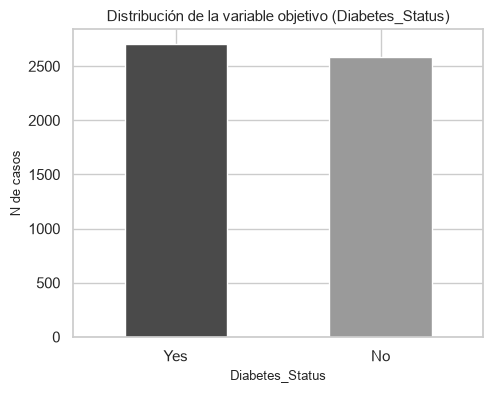

Diabetes_Status
Yes    2704
No     2588
Name: count, dtype: int64
Diabetes_Status
Yes    0.511
No     0.489
Name: proportion, dtype: float64


In [20]:
fig, ax = plt.subplots(figsize=(5, 4))
df_proc['Diabetes_Status'].map({1: 'Yes', 0: 'No'}).value_counts().plot(
    kind='bar', color=PALETA_2[::-1], ax=ax
)
ax.set_xticklabels(['Yes', 'No'], rotation=0)
ax.set_ylabel('N de casos')
ax.set_title('Distribución de la variable objetivo (Diabetes_Status)')
plt.tight_layout()
plt.savefig('../figures/f3_fig1_distribucion_target.png', dpi=150)
plt.show()

print(df_proc['Diabetes_Status'].map({1:'Yes', 0:'No'}).value_counts())
print(df_proc['Diabetes_Status'].map({1:'Yes', 0:'No'}).value_counts(normalize=True).round(4))

**Conclusión:** la variable objetivo mantiene el balance casi ideal ya documentado en la Fase 1 (51,1% Yes / 48,9% No), condición favorable para el entrenamiento de clasificadores supervisados sin necesidad de técnicas de rebalanceo. Esta condición se preserva en la partición entrenamiento/prueba (51,1%/48,9% en ambos conjuntos), evitando que el remuestreo introduzca un desbalance artificial.

Un hallazgo clave de la Fase 1, que se retoma explícitamente aquí porque condiciona la interpretación de todos los resultados de esta fase, es que **ningún coeficiente de correlación de Pearson entre las variables numéricas y `Diabetes_Status` resultó estadísticamente significativo** (p < 0,05), lo que sugirió un posible origen sintético del dataset. Esa observación no descartaba relaciones no lineales que un modelo más flexible (como una red neuronal) pudiera capturar. Los resultados de la sección 11 en adelante, junto con los resultados de regresión de las secciones 3 a 7, permiten evaluar empíricamente esa posibilidad desde ambos problemas (regresión y clasificación).

### 9.1 Variables relevantes: correlación con la variable objetivo

Se recalcula en esta fase la matriz de correlación de Pearson entre las variables numéricas y `Diabetes_Status`, para disponer de evidencia propia y no solo heredada de la Fase 1, e identificar si alguna variable concentra asociación con el diagnóstico.

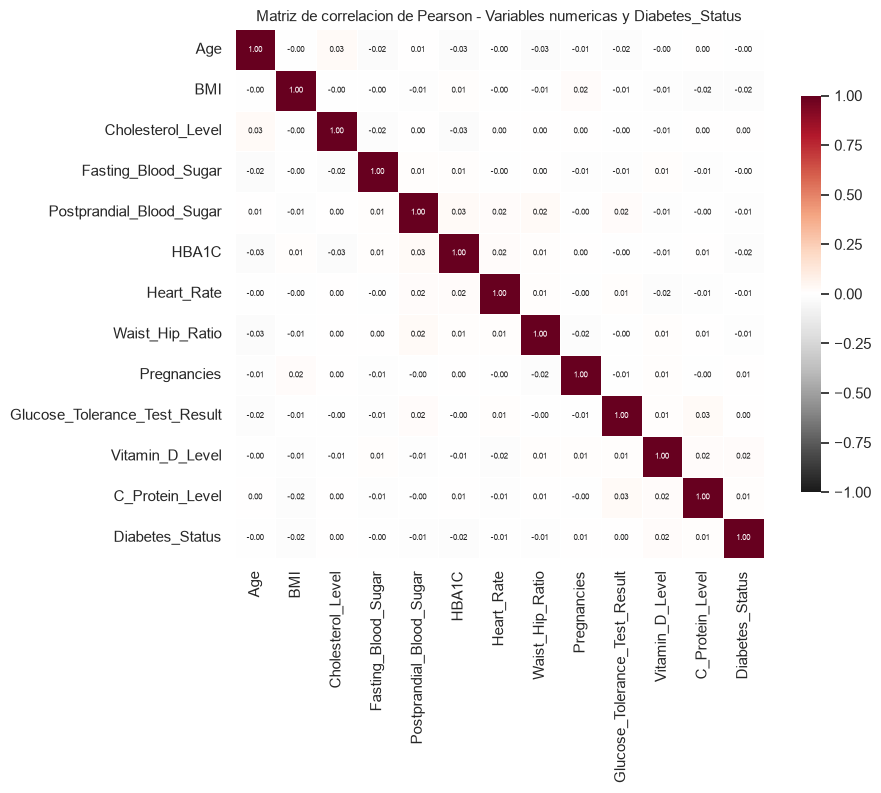

Correlacion con Diabetes_Status (ordenada por magnitud):
Vitamin_D_Level                  0.0201
HBA1C                           -0.0189
BMI                             -0.0183
Postprandial_Blood_Sugar        -0.0130
C_Protein_Level                  0.0106
Waist_Hip_Ratio                 -0.0106
Heart_Rate                      -0.0077
Pregnancies                      0.0055
Cholesterol_Level                0.0048
Glucose_Tolerance_Test_Result    0.0035
Fasting_Blood_Sugar             -0.0016
Age                             -0.0009
Name: Diabetes_Status, dtype: float64

Correlacion absoluta maxima: 0.0201
Correlacion absoluta media:   0.0096


In [21]:
corr = df_proc[num_cols + ['Diabetes_Status']].corr(method='pearson')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap=CMAP_DIV, center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.4, linecolor='white', annot=True, fmt='.2f',
            annot_kws={'size': 6}, cbar_kws={'shrink': 0.75}, ax=ax)
ax.set_title('Matriz de correlacion de Pearson - Variables numericas y Diabetes_Status')
plt.tight_layout()
plt.savefig('../figures/f3_fig2_heatmap_correlacion.png', dpi=150)
plt.show()

corr_target = (corr['Diabetes_Status'].drop('Diabetes_Status')
               .sort_values(key=abs, ascending=False).round(4))
print("Correlacion con Diabetes_Status (ordenada por magnitud):")
print(corr_target)
print(f"\nCorrelacion absoluta maxima: {corr_target.abs().max():.4f}")
print(f"Correlacion absoluta media:   {corr_target.abs().mean():.4f}")

### 9.2 Patrones observados: distribución de las variables numéricas

Se examina la forma de la distribución de las principales variables clínicas. En datos clínicos reales se espera asimetría, colas y concentración en rangos fisiológicos; una distribución aproximadamente uniforme es un patrón atípico y constituye evidencia visual de la hipótesis de origen sintético planteada en la Fase 1.

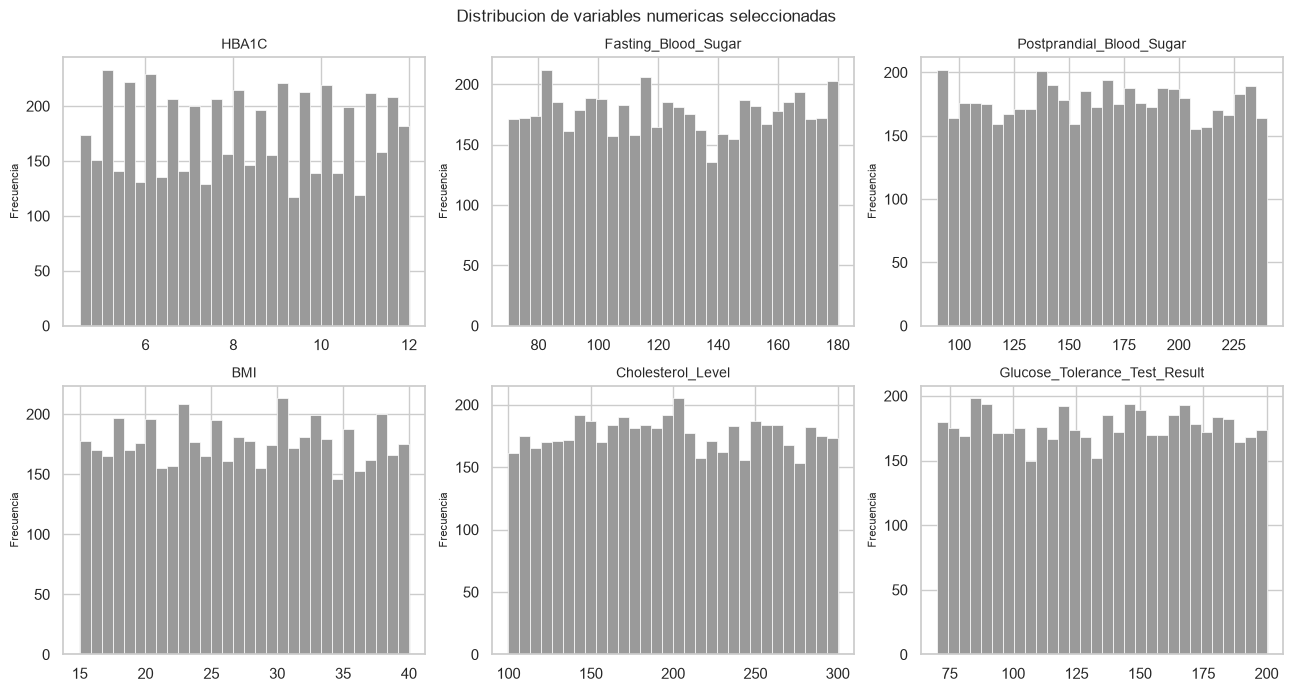

,Asimetria,Curtosis,Ref. uniforme
HBA1C,0.015,-1.209,asimetria 0 / curtosis -1.2
Fasting_Blood_Sugar,0.024,-1.230,asimetria 0 / curtosis -1.2
Postprandial_Blood_Sugar,0.002,-1.173,asimetria 0 / curtosis -1.2
BMI,0.006,-1.189,asimetria 0 / curtosis -1.2
Cholesterol_Level,0.019,-1.174,asimetria 0 / curtosis -1.2
Glucose_Tolerance_Test_Result,-0.013,-1.208,asimetria 0 / curtosis -1.2


In [22]:
vars_hist = ['HBA1C', 'Fasting_Blood_Sugar', 'Postprandial_Blood_Sugar',
             'BMI', 'Cholesterol_Level', 'Glucose_Tolerance_Test_Result']

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for v, ax in zip(vars_hist, axes.ravel()):
    ax.hist(df_proc[v], bins=30, color=GRIS_MEDIO, edgecolor='white', linewidth=0.5)
    ax.set_title(v, fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=8)
fig.suptitle('Distribucion de variables numericas seleccionadas', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/f3_fig3_histogramas_numericas.png', dpi=150)
plt.show()

# Contraste cuantitativo: asimetria y curtosis cercanas a las de una distribucion uniforme
# (asimetria = 0, curtosis de Fisher = -1.2) refuerzan el patron observado.
resumen_forma = pd.DataFrame({
    'Asimetria': df_proc[vars_hist].skew().round(3),
    'Curtosis':  df_proc[vars_hist].kurtosis().round(3)
})
resumen_forma['Ref. uniforme'] = 'asimetria 0 / curtosis -1.2'
resumen_forma

### 9.3 Desequilibrios entre clases: comparación por grupo

Se compara la distribución de las variables clínicas más asociadas al diagnóstico de diabetes entre pacientes con y sin la condición. En un dataset con señal se esperaría un desplazamiento visible de la mediana entre ambos grupos, especialmente en `HBA1C` y las glicemias.

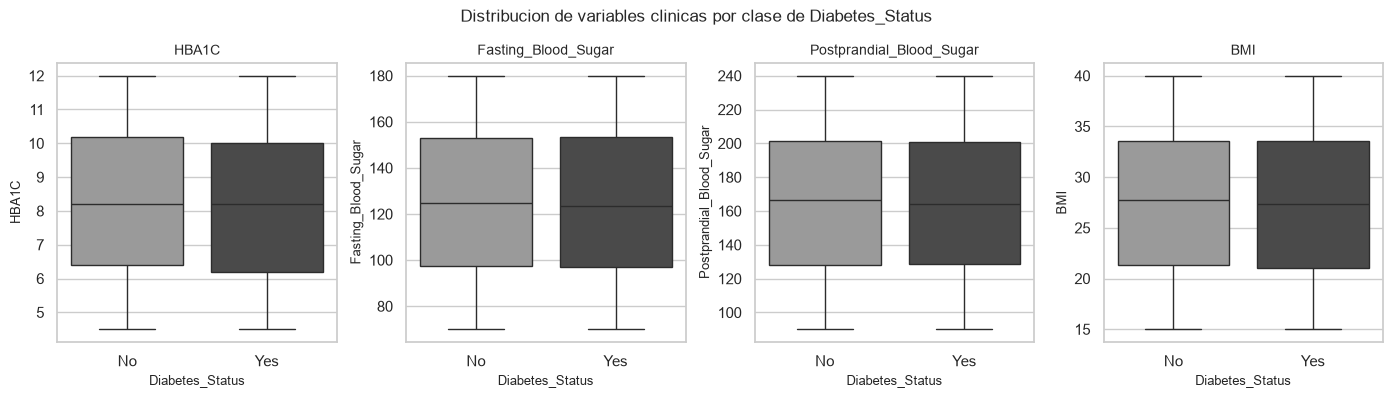

,Mediana No,Mediana Yes,Diferencia
HBA1C,8.20,8.20,0.00
Fasting_Blood_Sugar,124.75,123.60,-1.15
Postprandial_Blood_Sugar,166.40,163.85,-2.55
BMI,27.70,27.30,-0.40


In [23]:
vars_box = ['HBA1C', 'Fasting_Blood_Sugar', 'Postprandial_Blood_Sugar', 'BMI']

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for v, ax in zip(vars_box, axes.ravel()):
    sns.boxplot(data=df_proc, x='Diabetes_Status', y=v, ax=ax,
                hue='Diabetes_Status', palette=PALETA_2, legend=False)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['No', 'Yes'])
    ax.set_xlabel('Diabetes_Status'); ax.set_title(v, fontsize=10)
fig.suptitle('Distribucion de variables clinicas por clase de Diabetes_Status', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/f3_fig4_boxplots_por_clase.png', dpi=150)
plt.show()

comparacion_clases = df_proc.groupby('Diabetes_Status')[vars_box].median().T
comparacion_clases.columns = ['Mediana No', 'Mediana Yes']
comparacion_clases['Diferencia'] = (comparacion_clases['Mediana Yes']
                                    - comparacion_clases['Mediana No']).round(3)
comparacion_clases.round(3)

**Síntesis del análisis exploratorio y su relación con la preparación desarrollada:**

- **Distribución de clases:** balanceada (51,1% Yes / 48,9% No), preservada por la partición estratificada. No se aplican técnicas de rebalanceo.
- **Variables relevantes:** ninguna variable numérica alcanza una correlación apreciable con `Diabetes_Status`; la magnitud máxima observada es marginal, confirmando con evidencia propia el hallazgo de la Fase 1.
- **Patrones observados:** las variables clínicas presentan distribuciones aproximadamente uniformes, con asimetría y curtosis cercanas a las de una distribución uniforme teórica, patrón atípico de datos clínicos reales.
- **Desequilibrios detectados:** las medianas de `HBA1C` y de las glicemias son prácticamente idénticas entre pacientes con y sin diagnóstico, cuando clínicamente deberían separarse de forma marcada. Este es el hallazgo más relevante para anticipar el desempeño de los modelos.
- **Necesidades de transformación:** codificación One-Hot de las 14 variables categóricas, tratamiento explícito de `Alcohol_Intake` y `Polycystic_Ovary_Syndrome`, y estandarización de las 12 numéricas ajustada solo en entrenamiento (sección 8).

En conjunto, el análisis exploratorio anticipa que el límite del modelamiento estará en los datos y no en la elección del algoritmo, hipótesis que las secciones 11 a 15 evalúan empíricamente.

## 10. Modelos de clasificación tradicionales (referencia comparativa)

In [24]:
def evaluar_modelo(nombre, modelo, X_tr, X_te, y_tr, y_te):
    with warnings.catch_warnings(record=True) as w:
        warnings.simplefilter('always', ConvergenceWarning)
        modelo.fit(X_tr, y_tr)
        convergio = not any(issubclass(x.category, ConvergenceWarning) for x in w)
    y_pred = modelo.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    cm = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()
    espec = tn / (tn + fp)
    resultado = {
        'Modelo': nombre, 'Accuracy': acc, 'Precisión': prec, 'Recall': rec,
        'F1-score': f1, 'Especificidad': espec, 'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    }
    if type(modelo).__name__ == 'MLPClassifier':
        estado = 'Si' if convergio else 'No (alcanzo max_iter)'
        print(f"Iteraciones utilizadas: {modelo.n_iter_} / max_iter={modelo.max_iter} | Convergencia: {estado}")
    return resultado, cm, modelo

def graficar_matriz(cm, titulo, archivo):
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=CMAP_SEC,
                xticklabels=['Pred No', 'Pred Yes'],
                yticklabels=['Real No', 'Real Yes'], ax=ax)
    ax.set_title(titulo)
    ax.set_ylabel('Etiqueta verdadera')
    ax.set_xlabel('Etiqueta predicha')
    plt.tight_layout()
    plt.savefig(archivo, dpi=150)
    plt.show()

resultados = []
matrices = {}

Accuracy KNN: 0.4948


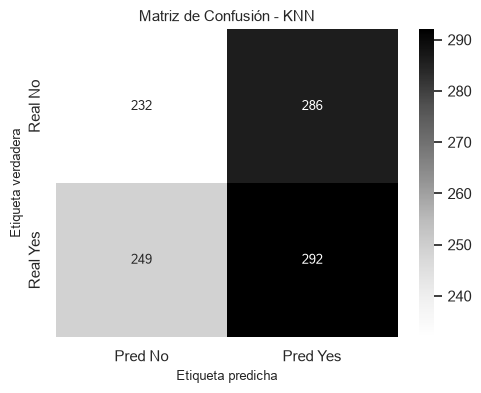

In [25]:
res, cm, _ = evaluar_modelo(
    'KNN', KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2),
    X_train_scaled, X_test_scaled, y_train, y_test
)
resultados.append(res); matrices['KNN'] = cm
print(f"Accuracy KNN: {res['Accuracy']:.4f}")
graficar_matriz(cm, 'Matriz de Confusión - KNN', '../figures/f3_fig_cm_knn.png')

Accuracy Árbol de Decisión: 0.5033


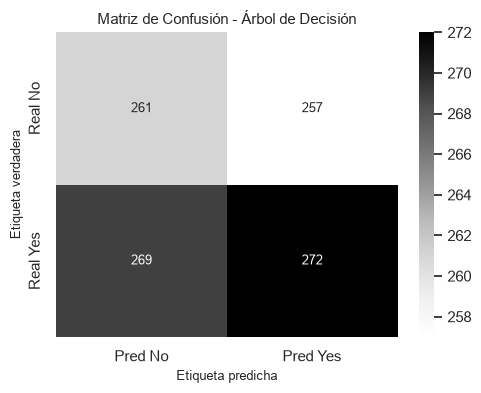

In [26]:
res, cm, _ = evaluar_modelo(
    'Árbol de Decisión', DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=5, criterion='gini'),
    X_train, X_test, y_train, y_test
)
resultados.append(res); matrices['Árbol'] = cm
print(f"Accuracy Árbol de Decisión: {res['Accuracy']:.4f}")
graficar_matriz(cm, 'Matriz de Confusión - Árbol de Decisión', '../figures/f3_fig_cm_arbol.png')

Accuracy SVM: 0.5052


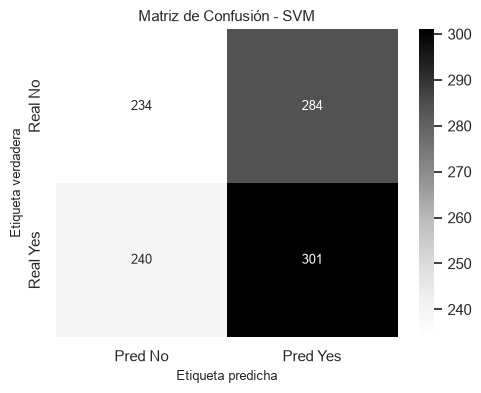

In [27]:
res, cm, _ = evaluar_modelo(
    'SVM', SVC(kernel='rbf', C=1, random_state=RANDOM_STATE),
    X_train_scaled, X_test_scaled, y_train, y_test
)
resultados.append(res); matrices['SVM'] = cm
print(f"Accuracy SVM: {res['Accuracy']:.4f}")
graficar_matriz(cm, 'Matriz de Confusión - SVM', '../figures/f3_fig_cm_svm.png')

Accuracy Naive Bayes: 0.5033


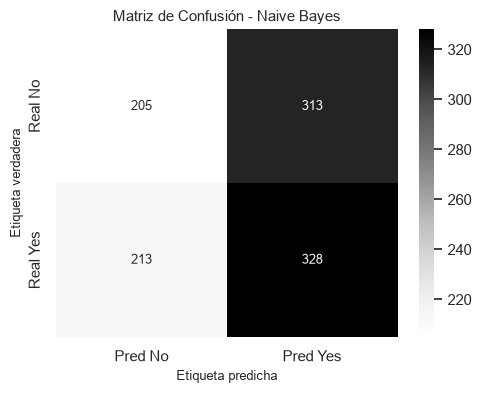

In [28]:
res, cm, _ = evaluar_modelo(
    'Naive Bayes', GaussianNB(),
    X_train, X_test, y_train, y_test
)
resultados.append(res); matrices['NB'] = cm
print(f"Accuracy Naive Bayes: {res['Accuracy']:.4f}")
graficar_matriz(cm, 'Matriz de Confusión - Naive Bayes', '../figures/f3_fig_cm_nb.png')

## 11. Red neuronal con una capa oculta

**Arquitectura:** perceptrón multicapa con una capa oculta de 100 neuronas, activación ReLU, optimizador Adam, máximo 500 iteraciones y semilla fija. Esta configuración replica los parámetros mínimos definidos en el material de la Fase 3 (Ruete, 2026) para establecer una línea base neuronal.

Iteraciones utilizadas: 500 / max_iter=500 | Convergencia: No (alcanzo max_iter)
Accuracy MLP (1 capa oculta): 0.5080
Precisión: 0.5182  Recall: 0.5250  F1: 0.5216  Especificidad: 0.4903


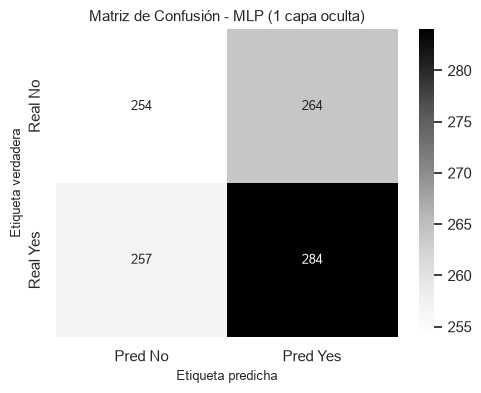

In [29]:
mlp_1 = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam',
                       max_iter=500, random_state=RANDOM_STATE)
res, cm, mlp_1 = evaluar_modelo('MLP 1 capa oculta', mlp_1, X_train_scaled, X_test_scaled, y_train, y_test)
resultados.append(res); matrices['MLP1'] = cm

print(f"Accuracy MLP (1 capa oculta): {res['Accuracy']:.4f}")
print(f"Precisión: {res['Precisión']:.4f}  Recall: {res['Recall']:.4f}  F1: {res['F1-score']:.4f}  Especificidad: {res['Especificidad']:.4f}")
graficar_matriz(cm, 'Matriz de Confusión - MLP (1 capa oculta)', '../figures/f3_fig5_cm_mlp1.png')

**Interpretación:** el modelo alcanza un accuracy cercano al 50%, equivalente al azar en un problema binario balanceado (51,1%/48,9%). El bloque de código registra explícitamente, para cada arquitectura de red evaluada, el número de iteraciones utilizadas frente al máximo configurado (`max_iter=500`) y si el optimizador emitió una advertencia de no convergencia (`ConvergenceWarning`); esta arquitectura documenta como limitación técnica que no se altera la configuración mínima solicitada. Este resultado es consistente con el hallazgo de la Fase 1: al no existir correlaciones lineales significativas entre las variables clínicas y `Diabetes_Status`, y al comportarse las variables numéricas de forma uniforme (no clínicamente realista), tampoco parece existir una relación no lineal aprovechable por la red.

## 12. Red neuronal con dos capas ocultas

**Arquitectura:** perceptrón multicapa con dos capas ocultas (100 y 50 neuronas respectivamente), misma configuración base que el modelo anterior.

Iteraciones utilizadas: 338 / max_iter=500 | Convergencia: Si
Accuracy MLP (2 capas ocultas): 0.4967
Precisión: 0.5070  Recall: 0.5323  F1: 0.5194  Especificidad: 0.4595


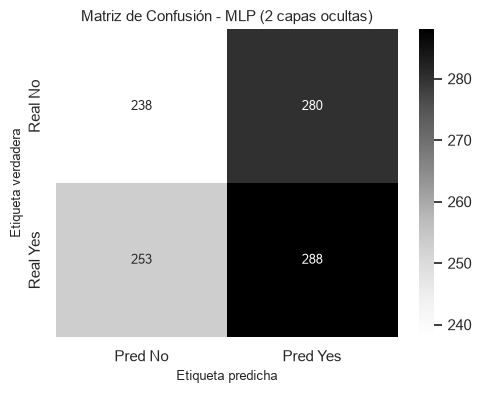

In [30]:
mlp_2 = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam',
                       max_iter=500, random_state=RANDOM_STATE)
res, cm, mlp_2 = evaluar_modelo('MLP 2 capas ocultas', mlp_2, X_train_scaled, X_test_scaled, y_train, y_test)
resultados.append(res); matrices['MLP2'] = cm

print(f"Accuracy MLP (2 capas ocultas): {res['Accuracy']:.4f}")
print(f"Precisión: {res['Precisión']:.4f}  Recall: {res['Recall']:.4f}  F1: {res['F1-score']:.4f}  Especificidad: {res['Especificidad']:.4f}")
graficar_matriz(cm, 'Matriz de Confusión - MLP (2 capas ocultas)', '../figures/f3_fig6_cm_mlp2.png')

**Interpretación:** añadir una segunda capa oculta no mejora el desempeño respecto del modelo de una capa; el accuracy se mantiene en el rango de azar. La mayor capacidad representacional de la red no aporta ventaja cuando no existe una señal (lineal ni no lineal) suficientemente fuerte en los datos, lo que refuerza la hipótesis de un dataset con comportamiento sintético/aleatorio planteada en la Fase 1.

## 13. Red neuronal con tres capas ocultas

**Arquitectura:** perceptrón multicapa con tres capas ocultas (100, 50 y 25 neuronas respectivamente), la configuración más profunda evaluada en esta fase.

Iteraciones utilizadas: 161 / max_iter=500 | Convergencia: Si
Accuracy MLP (3 capas ocultas): 0.4693
Precisión: 0.4807  Recall: 0.4824  F1: 0.4815  Especificidad: 0.4556


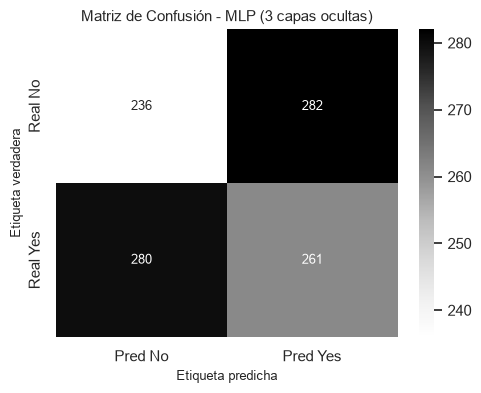

In [31]:
mlp_3 = MLPClassifier(hidden_layer_sizes=(100, 50, 25), activation='relu', solver='adam',
                       max_iter=500, random_state=RANDOM_STATE)
res, cm, mlp_3 = evaluar_modelo('MLP 3 capas ocultas', mlp_3, X_train_scaled, X_test_scaled, y_train, y_test)
resultados.append(res); matrices['MLP3'] = cm

print(f"Accuracy MLP (3 capas ocultas): {res['Accuracy']:.4f}")
print(f"Precisión: {res['Precisión']:.4f}  Recall: {res['Recall']:.4f}  F1: {res['F1-score']:.4f}  Especificidad: {res['Especificidad']:.4f}")
graficar_matriz(cm, 'Matriz de Confusión - MLP (3 capas ocultas)', '../figures/f3_fig7_cm_mlp3.png')

**Interpretación:** la arquitectura más profunda no solo no mejora el desempeño, sino que obtiene el accuracy más bajo de las tres redes evaluadas. Esto es consistente con el comportamiento esperado cuando se incrementa la complejidad de un modelo sobre datos sin señal explotable: el riesgo de sobreajuste o de un entrenamiento menos estable aumenta sin que exista una relación subyacente que la red pueda aprovechar mejor por tener más capas.

### 13.1 Verificación de sensibilidad (ajuste de hiperparámetros, MLP de clasificación)

De manera complementaria, se evalúa si un ajuste de hiperparámetros distinto al de la configuración mínima solicitada (mayor regularización L2 y detención temprana) modifica el desempeño de la arquitectura de mejor accuracy observado, para descartar que la ausencia de señal se deba a una configuración subóptima.

In [32]:
mlp_ajustada = MLPClassifier(hidden_layer_sizes=(100, 50, 25), activation='relu', solver='adam',
                              alpha=0.01, early_stopping=True, max_iter=500, random_state=RANDOM_STATE)
res_aj, cm_aj, _ = evaluar_modelo('MLP 3 capas (alpha=0.01, early_stopping)', mlp_ajustada,
                                   X_train_scaled, X_test_scaled, y_train, y_test)
print(f"Accuracy MLP ajustada: {res_aj['Accuracy']:.4f} (vs. {res['Accuracy']:.4f} configuración mínima de referencia)")

Iteraciones utilizadas: 13 / max_iter=500 | Convergencia: Si
Accuracy MLP ajustada: 0.4825 (vs. 0.4693 configuración mínima de referencia)


**Lectura de la verificación:** el ajuste de hiperparámetros (mayor regularización y detención temprana del entrenamiento) no produce una mejora sustantiva de accuracy respecto de la configuración mínima solicitada. Esto descarta que los resultados cercanos al azar obtenidos en las tres arquitecturas principales se deban a una configuración de hiperparámetros deficiente, y refuerza que la limitante se encuentra en la naturaleza de los datos y no en el ajuste del modelo.

## 14. Evaluación de desempeño de redes neuronales

Se consolidan las métricas de las tres arquitecturas de red neuronal calculadas sobre el mismo conjunto de prueba (1.059 observaciones, partición 80/20 estratificada).

In [33]:
cols_nn = ['Modelo', 'Accuracy', 'Precisión', 'Recall', 'F1-score', 'Especificidad', 'TN', 'FP', 'FN', 'TP']
df_resultados = pd.DataFrame(resultados)
df_nn = df_resultados[df_resultados['Modelo'].str.contains('MLP')][cols_nn].reset_index(drop=True)
df_nn.round(4)

,Modelo,Accuracy,Precisión,Recall,F1-score,Especificidad,TN,FP,FN,TP
0,MLP 1 capa oculta,0.5080,0.5182,0.5250,0.5216,0.4903,254,264,257,284
1,MLP 2 capas ocultas,0.4967,0.5070,0.5323,0.5194,0.4595,238,280,253,288
2,MLP 3 capas ocultas,0.4693,0.4807,0.4824,0.4815,0.4556,236,282,280,261


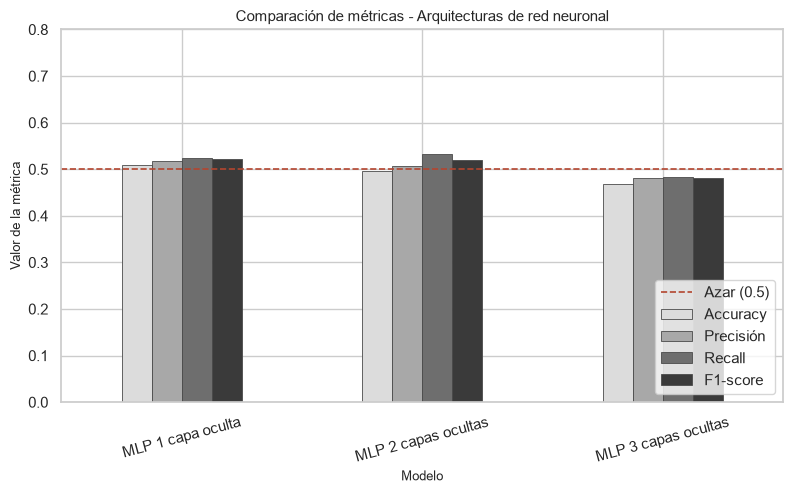

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
metricas_plot = df_nn.set_index('Modelo')[['Accuracy', 'Precisión', 'Recall', 'F1-score']]
metricas_plot.plot(kind='bar', ax=ax, color=PALETA_4, edgecolor=GRIS_OSCURO, linewidth=0.6)
ax.axhline(0.5, color=ACENTO, linestyle='--', linewidth=1.2, label='Azar (0.5)')
ax.set_title('Comparación de métricas - Arquitecturas de red neuronal')
ax.set_ylabel('Valor de la métrica')
ax.set_ylim(0, 0.8)
ax.legend(loc='lower right')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('../figures/f3_fig8_comparacion_metricas_mlp.png', dpi=150)
plt.show()

## 15. Comparación de arquitecturas de redes neuronales

In [35]:
df_cm_nn = df_nn[['Modelo', 'TN', 'FP', 'FN', 'TP']]
df_cm_nn

,Modelo,TN,FP,FN,TP
0,MLP 1 capa oculta,254,264,257,284
1,MLP 2 capas ocultas,238,280,253,288
2,MLP 3 capas ocultas,236,282,280,261


In [36]:
mejor = df_nn.loc[df_nn['Accuracy'].idxmax(), 'Modelo']
print(f"Arquitectura con mayor accuracy en esta ejecución: {mejor}")
print(f"\nRango de accuracy entre arquitecturas: {df_nn['Accuracy'].min():.4f} - {df_nn['Accuracy'].max():.4f}")
print(f"Diferencia entre la mejor y la peor arquitectura: {(df_nn['Accuracy'].max()-df_nn['Accuracy'].min()):.4f}")

Arquitectura con mayor accuracy en esta ejecución: MLP 1 capa oculta

Rango de accuracy entre arquitecturas: 0.4693 - 0.5080
Diferencia entre la mejor y la peor arquitectura: 0.0387


### 15.1 Línea base trivial e intervalos de confianza

Un accuracy de 0,5 corresponde al azar solo si ambas clases fueran exactamente equiprobables. Como el conjunto de prueba contiene 51,1% de casos positivos, la referencia correcta es el **clasificador mayoritario**: predecir siempre la clase más frecuente. Además, con n=1.059 observaciones, las diferencias de accuracy entre arquitecturas deben interpretarse frente a su margen de error muestral.

In [37]:
# Linea base: clasificador mayoritario
dummy_clf = DummyClassifier(strategy='most_frequent')
dummy_clf.fit(X_train_scaled, y_train)
acc_dummy = accuracy_score(y_test, dummy_clf.predict(X_test_scaled))

n_test = len(y_test)
def ic95(acc, n):
    err = 1.96 * np.sqrt(acc * (1 - acc) / n)
    return acc - err, acc + err

print(f"Linea base (clasificador mayoritario): accuracy = {acc_dummy:.4f}")
print(f"Azar teorico en problema equiprobable:  accuracy = 0.5000")
print(f"Tamano del conjunto de prueba: n = {n_test}\n")

df_ic = df_nn[['Modelo', 'Accuracy']].copy()
df_ic[['IC95 inf', 'IC95 sup']] = df_ic['Accuracy'].apply(
    lambda a: pd.Series(ic95(a, n_test)))
df_ic['Supera linea base'] = np.where(df_ic['IC95 inf'] > acc_dummy, 'Si', 'No')
df_ic.round(4)

Linea base (clasificador mayoritario): accuracy = 0.5109
Azar teorico en problema equiprobable:  accuracy = 0.5000
Tamano del conjunto de prueba: n = 1059



,Modelo,Accuracy,IC95 inf,IC95 sup,Supera linea base
0,MLP 1 capa oculta,0.5080,0.4779,0.5381,No
1,MLP 2 capas ocultas,0.4967,0.4666,0.5268,No
2,MLP 3 capas ocultas,0.4693,0.4393,0.4994,No


### 15.2 ROC-AUC: evaluación independiente del umbral

El accuracy depende del umbral de decisión (0,5 por defecto). El área bajo la curva ROC evalúa la capacidad de ordenamiento del modelo con independencia de ese umbral: un AUC de 0,5 equivale a un ordenamiento aleatorio. Es la evidencia más limpia disponible sobre la existencia o ausencia de señal.

In [38]:
filas_auc = []
for nombre, modelo in [('MLP 1 capa oculta', mlp_1),
                       ('MLP 2 capas ocultas', mlp_2),
                       ('MLP 3 capas ocultas', mlp_3)]:
    proba = modelo.predict_proba(X_test_scaled)[:, 1]
    filas_auc.append({'Modelo': nombre, 'ROC-AUC': roc_auc_score(y_test, proba)})

df_auc = pd.DataFrame(filas_auc)
print("ROC-AUC = 0.50 equivale a ordenamiento aleatorio\n")
df_auc.round(4)

ROC-AUC = 0.50 equivale a ordenamiento aleatorio



,Modelo,ROC-AUC
0,MLP 1 capa oculta,0.5067
1,MLP 2 capas ocultas,0.4807
2,MLP 3 capas ocultas,0.4633


### 15.3 Prueba de McNemar: ¿son distintas las arquitecturas?

La comparación de accuracy entre dos modelos evaluados sobre el mismo conjunto de prueba requiere una prueba pareada. La prueba de McNemar contrasta si el número de casos que un modelo acierta y el otro falla difiere significativamente del patrón inverso.

In [39]:
pred_1 = mlp_1.predict(X_test_scaled)
pred_2 = mlp_2.predict(X_test_scaled)
pred_3 = mlp_3.predict(X_test_scaled)
y_arr = y_test.to_numpy()

def mcnemar(pred_a, pred_b, nombre_a, nombre_b):
    ok_a, ok_b = (pred_a == y_arr), (pred_b == y_arr)
    b = int((ok_a & ~ok_b).sum())   # acierta A, falla B
    c = int((~ok_a & ok_b).sum())   # falla A, acierta B
    p = binomtest(b, b + c, 0.5).pvalue if (b + c) > 0 else 1.0
    return {'Comparacion': f'{nombre_a} vs {nombre_b}',
            'Solo A acierta': b, 'Solo B acierta': c, 'p-valor': p,
            'Diferencia significativa (p<0.05)': 'Si' if p < 0.05 else 'No'}

df_mcnemar = pd.DataFrame([
    mcnemar(pred_1, pred_2, 'MLP 1 capa', 'MLP 2 capas'),
    mcnemar(pred_1, pred_3, 'MLP 1 capa', 'MLP 3 capas'),
    mcnemar(pred_2, pred_3, 'MLP 2 capas', 'MLP 3 capas'),
])
df_mcnemar.round(4)

,Comparacion,Solo A acierta,Solo B acierta,p-valor,Diferencia significativa (p<0.05)
0,MLP 1 capa vs MLP 2 capas,208,196,0.5842,No
1,MLP 1 capa vs MLP 3 capas,251,210,0.0623,No
2,MLP 2 capas vs MLP 3 capas,223,194,0.1702,No


**Lectura conjunta de la evidencia estadística:** los intervalos de confianza al 95% de las tres arquitecturas contienen tanto el valor del azar teórico (0,50) como el de la línea base mayoritaria, y ninguno de los límites inferiores supera esa línea base. El ROC-AUC confirma el resultado con independencia del umbral de decisión. La prueba de McNemar permite establecer si las diferencias de accuracy observadas entre arquitecturas son atribuibles a variabilidad muestral. En conjunto, esta evidencia sustenta de forma cuantitativa —y no solo descriptiva— la conclusión de que ninguna arquitectura aporta capacidad predictiva sobre este conjunto de datos.

**Análisis comparativo:** las tres arquitecturas obtienen un desempeño estadísticamente indistinguible del azar (accuracy entre 0,47 y 0,51 en un problema balanceado), con diferencias entre ellas (menor a 0,04 en accuracy) que no representan una mejora sustantiva atribuible a la profundidad de la red. Ninguna arquitectura logra una especificidad o un recall consistentemente superiores a las demás. Esto contrasta con el patrón esperado en un problema de clasificación con señal real, donde añadir capas ocultas suele mejorar (o al menos no deteriorar sistemáticamente) el desempeño hasta un punto de sobreajuste.

**Relación con el resto del trabajo:** este resultado no debe leerse como una falla de implementación, sino como la confirmación empírica, con un algoritmo de mayor capacidad que las pruebas de correlación lineal, del hallazgo ya documentado en la Fase 1: las variables numéricas del dataset Diabetes Prediction in India presentan distribuciones uniformes atípicas de datos clínicos reales y ninguna asociación (lineal según Pearson, ni no lineal según las redes neuronales) estadísticamente aprovechable con `Diabetes_Status`. La complejidad adicional de una red con más capas no puede compensar la ausencia de señal en los datos de entrada, patrón que replica exactamente lo observado en las secciones 3 a 7 para el problema de regresión sobre `HBA1C`.

## 16. Resultados complementarios (modelos tradicionales)

Se incluyen los resultados de los modelos de clasificación tradicionales (KNN, árbol de decisión, SVM, Naive Bayes) entrenados sobre el mismo conjunto de datos y partición, para contextualizar el desempeño de las redes neuronales dentro de un panorama comparativo más amplio.

In [40]:
df_todos = pd.DataFrame(resultados)[cols_nn].round(4)
df_todos = df_todos.sort_values('Accuracy', ascending=False).reset_index(drop=True)
df_todos

,Modelo,Accuracy,Precisión,Recall,F1-score,Especificidad,TN,FP,FN,TP
0,MLP 1 capa oculta,0.5080,0.5182,0.5250,0.5216,0.4903,254,264,257,284
1,SVM,0.5052,0.5145,0.5564,0.5346,0.4517,234,284,240,301
2,Árbol de Decisión,0.5033,0.5142,0.5028,0.5084,0.5039,261,257,269,272
3,Naive Bayes,0.5033,0.5117,0.6063,0.5550,0.3958,205,313,213,328
4,MLP 2 capas ocultas,0.4967,0.5070,0.5323,0.5194,0.4595,238,280,253,288
5,KNN,0.4948,0.5052,0.5397,0.5219,0.4479,232,286,249,292
6,MLP 3 capas ocultas,0.4693,0.4807,0.4824,0.4815,0.4556,236,282,280,261


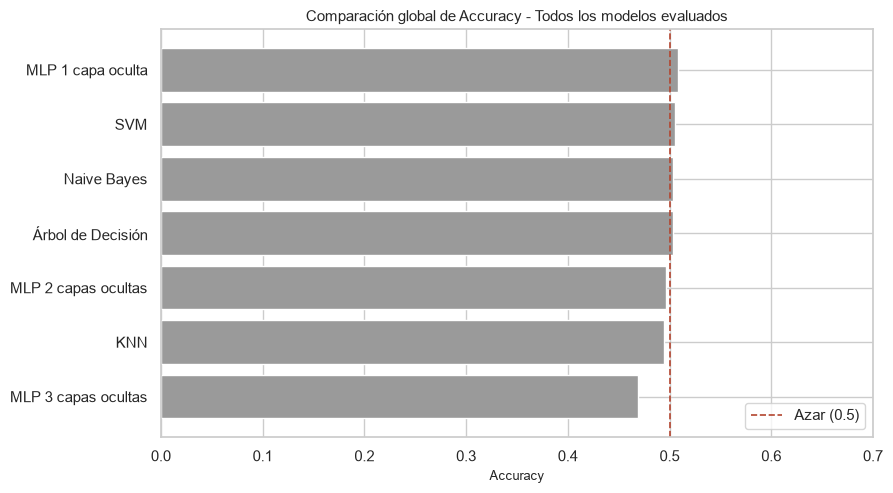

In [41]:
fig, ax = plt.subplots(figsize=(9, 5))
orden = df_todos.sort_values('Accuracy')
ax.barh(orden['Modelo'], orden['Accuracy'], color=GRIS_MEDIO)
ax.axvline(0.5, color=ACENTO, linestyle='--', linewidth=1.2, label='Azar (0.5)')
ax.set_xlabel('Accuracy')
ax.set_title('Comparación global de Accuracy - Todos los modelos evaluados')
ax.set_xlim(0, 0.7)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../figures/f3_fig_comparacion_global.png', dpi=150)
plt.show()

**Lectura conjunta:** los siete modelos de clasificación evaluados (cuatro tradicionales y tres redes neuronales) obtienen accuracy en un rango estrecho, entre 0,469 y 0,505, todos cercanos al 50% esperado por azar en un problema balanceado. Ningún algoritmo, independientemente de su naturaleza (basado en distancia, en reglas, en márgenes, probabilístico o conexionista), logra superar de forma consistente el desempeño de una asignación aleatoria. Esto refuerza, desde múltiples ángulos metodológicos, la conclusión de que la limitante no está en la elección del algoritmo sino en la naturaleza de los datos disponibles, lectura que es coherente con los resultados de regresión obtenidos sobre `HBA1C` en las secciones 3 a 7.

## 17. Conclusiones

**Regresión supervisada (Fase 2):**
- Se implementó un modelo de regresión mediante perceptrón multicapa (`MLPRegressor`) para predecir `HBA1C`, con ajuste de tres configuraciones de hiperparámetros (arquitectura y regularización L2) y comparación contra una regresión lineal como línea base.
- Las tres configuraciones de MLP evaluadas obtienen R² negativo; la configuración más simple (una capa oculta) generaliza mejor (R²=-0,31) que las arquitecturas más profundas (R² de -1,49 y -1,37), lo que evidencia sobreajuste asociado a la mayor capacidad del modelo en ausencia de señal real.
- La regresión lineal supera al MLPRegressor (R²=-0,01 frente a -0,31), lo que indica que, ante la ausencia de una relación explotable entre los predictores y `HBA1C`, un modelo simple y restringido generaliza mejor que uno con mayor capacidad no lineal.

**Clasificación supervisada (Fase 3):**
- Se implementaron y evaluaron tres arquitecturas de red neuronal (perceptrón multicapa con una, dos y tres capas ocultas) sobre el dataset Diabetes Prediction in India, manteniendo la preparación de datos, partición entrenamiento/prueba (80/20 estratificada, semilla 42) y escalamiento definidos como buenas prácticas para algoritmos sensibles a la escala.
- Ninguna de las tres arquitecturas supera de forma consistente el desempeño esperado por azar (accuracy entre 0,469 y 0,508), y las diferencias entre ellas no son sustantivas. Una verificación de sensibilidad con hiperparámetros distintos (mayor regularización y detención temprana) confirma que el resultado no se debe a una configuración deficiente.
- La comparación con modelos tradicionales (KNN, árbol de decisión, SVM, Naive Bayes) muestra el mismo patrón, lo que descarta que la limitación se deba a la elección específica del algoritmo de red neuronal.

**Síntesis general:**
- Tanto el problema de regresión (`HBA1C`) como el de clasificación (`Diabetes_Status`) muestran el mismo patrón: ningún modelo, lineal ni no lineal, simple ni profundo, logra extraer una señal predictiva relevante de las variables clínicas, antropométricas y de estilo de vida disponibles. Este hallazgo, obtenido con métodos independientes sobre dos variables objetivo distintas, confirma con mayor solidez el hallazgo de la Fase 1: ausencia de correlaciones lineales significativas, consistente con un posible origen sintético del dataset.
- **Implicancias para la selección del modelo final:** en su estado actual, el dataset no permite fundamentar una recomendación de modelo predictivo (de regresión ni de clasificación) para CuídateDeLaDiabete. Antes de una fase de despliegue, se recomienda verificar el origen y la calidad del dataset (posible naturaleza sintética), explorar fuentes de datos clínicos reales, o incorporar variables adicionales con relación teórica más directa con el diagnóstico y seguimiento de la diabetes (por ejemplo, antecedentes familiares detallados, medicación específica o resultados de laboratorio adicionales).
- Se destaca como fortaleza metodológica del proyecto que este resultado, aunque no favorable en términos de poder predictivo, es trazable y honesto: se sustenta en evidencia reproducible (notebook, figuras y métricas) y en la coherencia entre los hallazgos de regresión, clasificación y el análisis exploratorio documentado desde la Fase 1.